# Data Fusion Contest 2026 — Задача 2 «Киберполка

## Описание задачи
Нужно предсказать вероятности открытия 41 банковского продукта (multi-label классификация). Метрика — Macro Averaged ROC-AUC (среднее ROC-AUC по всем классам).

## Входные файлы
- `train_main_features.parquet`
- `train_extra_features.parquet`
- `test_main_features.parquet`
- `test_extra_features.parquet`
- `train_target.parquet`
- `sample_submit.parquet`

## Автор: Роман Тамразов


## Содержание
1. Импорты и параметры
2. Загрузка данных (Polars lazy)
3. Feature engineering в Polars
4. Материализация в pandas
5. EDA и визуализации
6. SVD и кластеризация
7. Отбор признаков (quick CatBoost)
8. Pseudo-labeling
9. Финальная модель, метрика, submission


## Импорты
Импорты для работы с parquet (Polars/PyArrow), построения фичей, обучения CatBoost и оценки качества.

In [1]:
import os, gc
import time, math
import numpy as np
import pandas as pd
import polars as pl
from catboost import Pool, CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import roc_auc_score
import pyarrow as pa
import pyarrow.parquet as pq


## Настройки
Ключевые параметры пайплайна: сид, лимиты итераций, ранняя остановка, параметры отбора признаков и псевдомаркирования.

In [32]:
RANDOM_SEED = 42
ITER_FINAL = 2000
EARLY_STOP = 200
TOP_FEATS = 1500
USE_PSEUDO = True
PSEUDO_WEIGHT = 0.2
SVD_COMPONENTS = 60
KMEANS_CLUSTERS = 40
RSM = 1
FINAL_SUBMIT = 'submission_0_836.parquet'


## Пути к данным
Пути к parquet-файлам. По умолчанию ожидаются в текущей директории ноутбука.

In [39]:
# Используйте свои пути
TRAIN_MAIN_PATH = 'train_main_features.parquet'
TRAIN_EXTRA_PATH = 'train_extra_features.parquet'
TEST_MAIN_PATH = 'test_main_features.parquet'
TEST_EXTRA_PATH = 'test_extra_features.parquet'
TARGET_PATH = 'train_target.parquet'
SAMPLE_SUB_PATH = 'sample_submit.parquet'


## Загрузка данных (Polars lazy)
Чтение parquet в ленивом режиме и объединение `main` и `extra` по `customer_id`. Здесь же формируются списки `cat_features` и `num_features`.

In [4]:
print("Загрузка данных (lazy)...")
train_main = pl.scan_parquet(TRAIN_MAIN_PATH)
train_extra = pl.scan_parquet(TRAIN_EXTRA_PATH)
test_main = pl.scan_parquet(TEST_MAIN_PATH)
test_extra = pl.scan_parquet(TEST_EXTRA_PATH)
train_lazy = train_main.join(train_extra, on='customer_id', how='left')
test_lazy = test_main.join(test_extra, on='customer_id', how='left')
schema = train_lazy.collect_schema()
cat_features = [c for c in schema if c.startswith('cat_feature')]
num_features = [c for c in schema if c.startswith('num_feature')]
print(f"Категориальных: {len(cat_features)}, числовых: {len(num_features)}")


Загрузка данных (lazy)...
Категориальных: 67, числовых: 2373


## Заполнение категориальных признаков
Пропуски в категориальных признаках заменяются на -999 и приводятся к `Int32` для стабильного дальнейшего использования.

In [5]:
cat_fill_exprs = [pl.col(c).fill_null(-999).cast(pl.Int32) for c in cat_features]
train_lazy = train_lazy.with_columns(cat_fill_exprs)
test_lazy = test_lazy.with_columns(cat_fill_exprs)


## Базовые агрегаты по числовым признакам
Добавляются агрегаты по строке: число пропусков и нулей по всем `num_feature`, суммы по первым 50 числовым и раздельные суммы положительных/отрицательных значений.

In [6]:
top50 = num_features[:50]
stage1 = [
    pl.sum_horizontal([pl.col(c).is_null().cast(pl.Int32) for c in num_features]).alias('total_nulls'),
    pl.sum_horizontal([(pl.col(c) == 0).cast(pl.Int32) for c in num_features]).alias('total_zeros'),
    pl.sum_horizontal([pl.col(c).fill_null(0) for c in top50]).alias('sum_top50'),
    pl.sum_horizontal([pl.when(pl.col(c) > 0).then(pl.col(c)).otherwise(0).fill_null(0) for c in top50]).alias('sum_pos_top50'),
    pl.sum_horizontal([pl.when(pl.col(c) < 0).then(pl.col(c)).otherwise(0).fill_null(0) for c in top50]).alias('sum_neg_top50'),
]
train_lazy = train_lazy.with_columns(stage1)
test_lazy = test_lazy.with_columns(stage1)

stage2 = [
    (pl.col('sum_pos_top50') / (pl.col('sum_top50') + 1e-9)).alias('pos_ratio_top50'),
    (pl.col('sum_neg_top50') / (pl.col('sum_top50') + 1e-9)).alias('neg_ratio_top50'),
]
train_lazy = train_lazy.with_columns(stage2)
test_lazy = test_lazy.with_columns(stage2)


## Frequency encoding для категорий
Для первых 12 категориальных признаков добавляется частота встречаемости категории в train.

In [7]:
freq_cats = cat_features[:12]
for c in freq_cats:
    freq = train_lazy.group_by(c).agg(pl.count().alias(f'{c}_freq'))
    train_lazy = train_lazy.join(freq, on=c, how='left')
    test_lazy = test_lazy.join(freq, on=c, how='left')
    train_lazy = train_lazy.with_columns(pl.col(f'{c}_freq').fill_null(1).cast(pl.Float32))
    test_lazy = test_lazy.with_columns(pl.col(f'{c}_freq').fill_null(1).cast(pl.Float32))


/tmp/ipykernel_106/2163706207.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  freq = train_lazy.group_by(c).agg(pl.count().alias(f'{c}_freq'))


## Таргет-статистики по категориям
Для выбранных категориальных признаков считаются агрегаты по таргетам (mean/std по всем таргетам) и логарифм количества наблюдений в категории.

In [8]:
print("Добавляем статистики таргета по категориям...")
targets_lazy = pl.scan_parquet(TARGET_PATH)
target_cols = [c for c in targets_lazy.collect_schema().names() if c.startswith('target_')]
base = (
    train_main.join(train_extra, on='customer_id', how='left')
    .with_columns(cat_fill_exprs)
    .select(['customer_id'] + freq_cats)
    .join(targets_lazy, on='customer_id', how='left')
)
for c in freq_cats:
    mean_exprs = [pl.col(t).mean().alias(f'{t}_mean') for t in target_cols]
    agg = base.group_by(c).agg(mean_exprs)
    mean_h = pl.mean_horizontal([pl.col(f'{t}_mean') for t in target_cols])
    std_h = (pl.mean_horizontal([(pl.col(f'{t}_mean') - mean_h) ** 2 for t in target_cols])).sqrt()
    agg = agg.with_columns([
        mean_h.alias(f'{c}_targ_mean'), std_h.alias(f'{c}_targ_std'), pl.count().alias(f'{c}_cnt')
    ]).select([c, f'{c}_targ_mean', f'{c}_targ_std', f'{c}_cnt'])
    train_lazy = train_lazy.join(agg, on=c, how='left')
    test_lazy = test_lazy.join(agg, on=c, how='left')
    train_lazy = train_lazy.with_columns([
        pl.col(f'{c}_targ_mean').fill_null(0.0),
        pl.col(f'{c}_targ_std').fill_null(0.0),
        pl.col(f'{c}_cnt').fill_null(0).cast(pl.Float32)
    ]).with_columns([(pl.col(f'{c}_cnt') + 1).log().alias(f'{c}_cnt_log')])
    test_lazy = test_lazy.with_columns([
        pl.col(f'{c}_targ_mean').fill_null(0.0),
        pl.col(f'{c}_targ_std').fill_null(0.0),
        pl.col(f'{c}_cnt').fill_null(0).cast(pl.Float32)
    ]).with_columns([(pl.col(f'{c}_cnt') + 1).log().alias(f'{c}_cnt_log')])


Добавляем статистики таргета по категориям...


/tmp/ipykernel_106/202291052.py:16: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  mean_h.alias(f'{c}_targ_mean'), std_h.alias(f'{c}_targ_std'), pl.count().alias(f'{c}_cnt')


## Совмещения категорий (pair features)
Создаются новые категориальные признаки как конкатенация пар из первых 4 категориальных. Для них также считаются таргет-статистики.

In [9]:
merge_cats = freq_cats[:4]
for i, c1 in enumerate(merge_cats):
    for c2 in merge_cats[i+1:]:
        newcol = f"{c1}_{c2}"
        train_lazy = train_lazy.with_columns((pl.col(c1).cast(str) + "_" + pl.col(c2).cast(str)).alias(newcol))
        test_lazy  = test_lazy.with_columns ((pl.col(c1).cast(str) + "_" + pl.col(c2).cast(str)).alias(newcol))

        base_with_new = base.with_columns((pl.col(c1).cast(str) + "_" + pl.col(c2).cast(str)).alias(newcol))

        agg = base_with_new.group_by(newcol).agg([pl.col(t).mean().alias(f'{newcol}_{t}_mean') for t in target_cols])

        mean_h = pl.mean_horizontal([pl.col(f'{newcol}_{t}_mean') for t in target_cols])
        std_h  = (pl.mean_horizontal([(pl.col(f'{newcol}_{t}_mean') - mean_h) ** 2 for t in target_cols])).sqrt()
        agg = agg.with_columns([
            mean_h.alias(f'{newcol}_targ_mean'),
            std_h.alias(f'{newcol}_targ_std'),
            pl.len().alias(f'{newcol}_cnt')
        ]).select([newcol, f'{newcol}_targ_mean', f'{newcol}_targ_std', f'{newcol}_cnt'])

        train_lazy = train_lazy.join(agg, on=newcol, how='left')
        test_lazy  = test_lazy.join(agg,  on=newcol, how='left')

        train_lazy = train_lazy.with_columns([
            pl.col(f'{newcol}_targ_mean').fill_null(0.0),
            pl.col(f'{newcol}_targ_std').fill_null(0.0),
            pl.col(f'{newcol}_cnt').fill_null(0).cast(pl.Float32)
        ]).with_columns([(pl.col(f'{newcol}_cnt') + 1).log().alias(f'{newcol}_cnt_log')])

        test_lazy = test_lazy.with_columns([
            pl.col(f'{newcol}_targ_mean').fill_null(0.0),
            pl.col(f'{newcol}_targ_std').fill_null(0.0),
            pl.col(f'{newcol}_cnt').fill_null(0).cast(pl.Float32)
        ]).with_columns([(pl.col(f'{newcol}_cnt') + 1).log().alias(f'{newcol}_cnt_log')])

        cat_features.append(newcol)


## Материализация в pandas
Сбор всех рассчитанных признаков в `train_df` и `test_df`, загрузка таргетов в `y_df` и освобождение промежуточных объектов.

In [10]:
print("Материализация и дополнительные преобразования...")
all_cols = [c for c in train_lazy.collect_schema().names() if c not in ('customer_id')]
train_df = train_lazy.select(all_cols).collect().to_pandas()
test_df = test_lazy.select(all_cols).collect().to_pandas()
customer_ids = test_lazy.select('customer_id').collect().to_pandas()['customer_id'].astype(np.int32).values
y_df = pl.scan_parquet(TARGET_PATH).collect().drop('customer_id').to_pandas()

del train_lazy, test_lazy, base, train_main, train_extra, test_main, test_extra, targets_lazy
gc.collect()


Материализация и дополнительные преобразования...


0

## EDA: быстрые проверки и визуализации
Ниже несколько лёгких диагностик, которые помогают понять данные и качество фичей. Все графики строятся на сэмплах, чтобы не перегружать память.

In [11]:
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except Exception:
    sns = None

print('train_df:', train_df.shape)
print('test_df:', test_df.shape)
print('y_df:', y_df.shape)


train_df: (750000, 2537)
test_df: (250000, 2537)
y_df: (750000, 41)


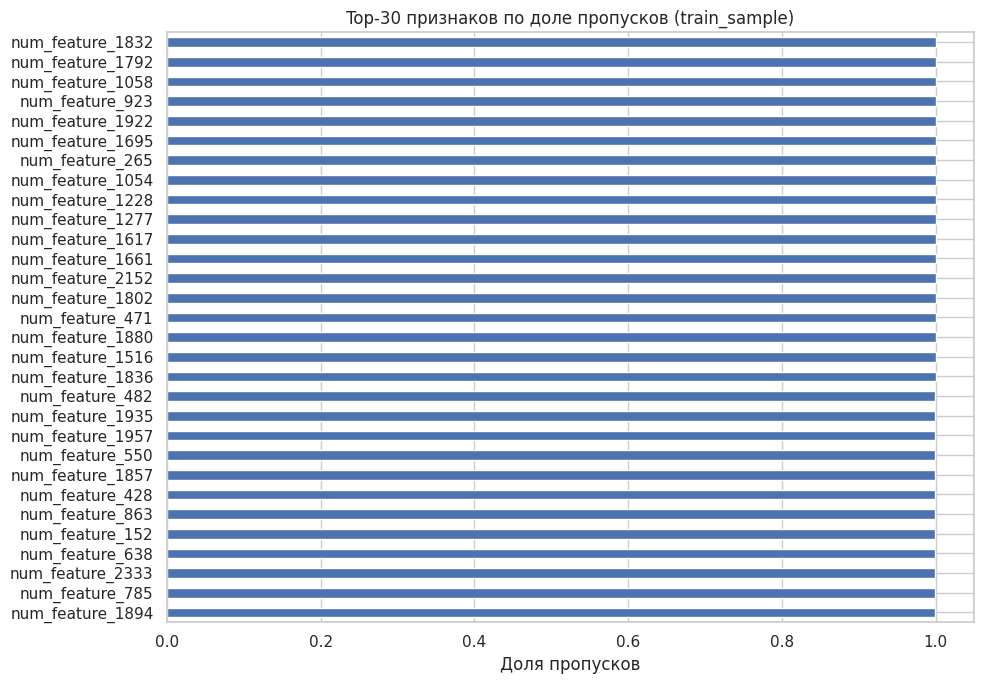

In [13]:
sample_n = min(100000, len(train_df))
train_sample = train_df.sample(n=sample_n, random_state=RANDOM_SEED)

missing = train_sample.isna().mean().sort_values(ascending=False)
top_missing = missing.head(30)

plt.figure(figsize=(10, 7))
top_missing.iloc[::-1].plot(kind='barh')
plt.title('Top-30 признаков по доле пропусков (train_sample)')
plt.xlabel('Доля пропусков')
plt.tight_layout()
plt.show()


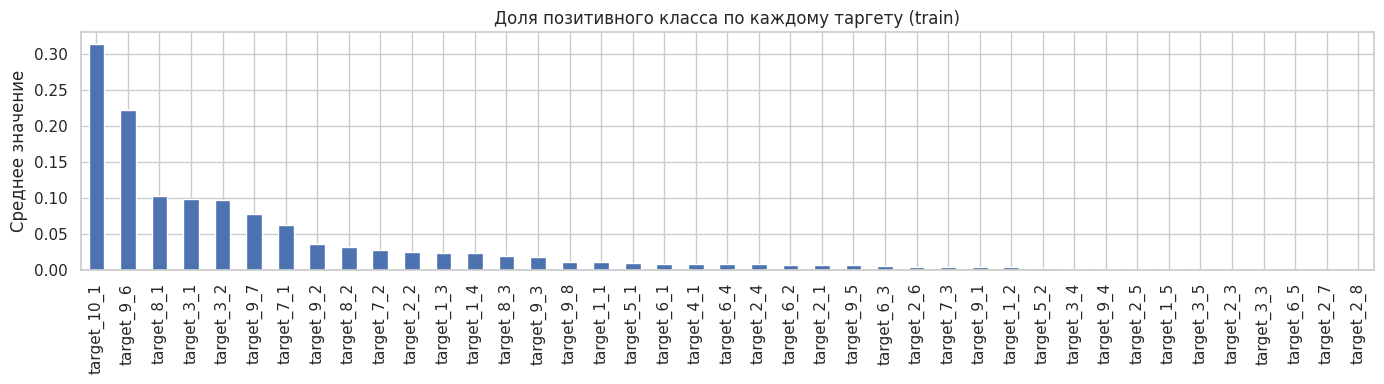

In [14]:
target_rate = y_df.mean().sort_values(ascending=False)

plt.figure(figsize=(14, 4))
target_rate.plot(kind='bar')
plt.title('Доля позитивного класса по каждому таргету (train)')
plt.ylabel('Среднее значение')
plt.tight_layout()
plt.show()


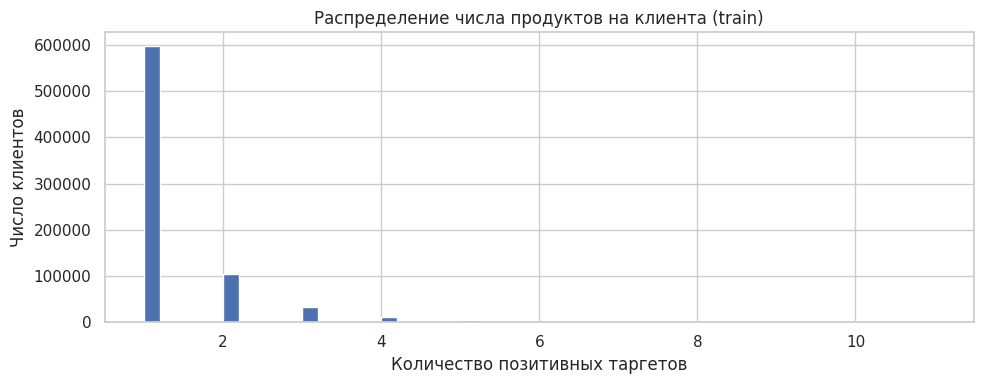

In [15]:
y_count = y_df.sum(axis=1)

plt.figure(figsize=(10, 4))
plt.hist(y_count, bins=50)
plt.title('Распределение числа продуктов на клиента (train)')
plt.xlabel('Количество позитивных таргетов')
plt.ylabel('Число клиентов')
plt.tight_layout()
plt.show()


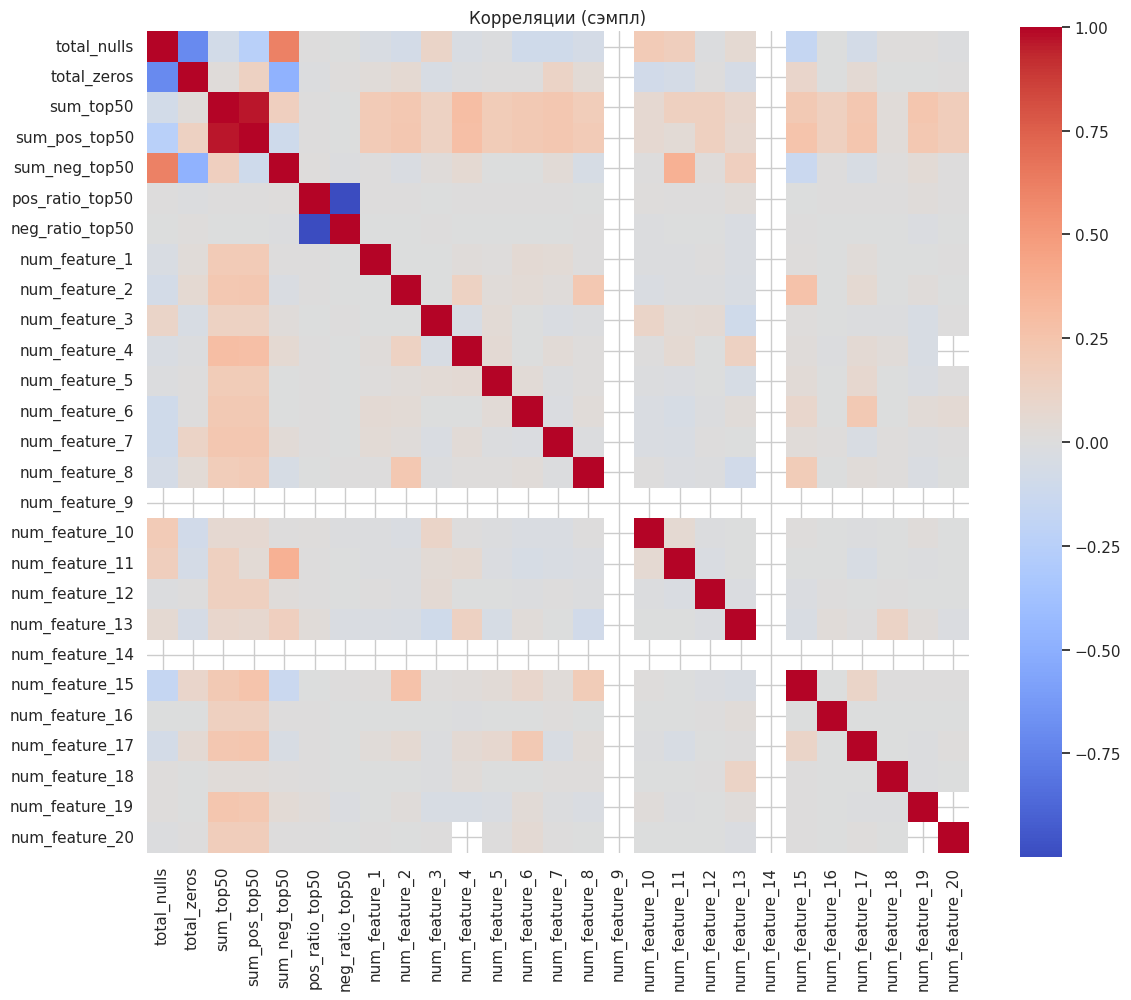

In [16]:
base_cols = [
    'total_nulls', 'total_zeros',
    'sum_top50', 'sum_pos_top50', 'sum_neg_top50',
    'pos_ratio_top50', 'neg_ratio_top50'
]
base_cols = [c for c in base_cols if c in train_df.columns]
num_head = [c for c in train_df.columns if c.startswith('num_feature')][:20]
corr_cols = base_cols + num_head

corr_sample = train_df[corr_cols].sample(n=min(50000, len(train_df)), random_state=RANDOM_SEED)
corr = corr_sample.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
if sns is not None:
    sns.heatmap(corr, cmap='coolwarm', center=0, square=True)
else:
    plt.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
    plt.yticks(range(len(corr_cols)), corr_cols)
plt.title('Корреляции (сэмпл)')
plt.tight_layout()
plt.show()


## Обработка числовых признаков
Winsorize (1–99 перцентили), логарифмы сумм и глобальные агрегаты по всем `num_feature`. Дополнительно подготавливается `scaler` по сэмплу для следующих шагов.

In [20]:
import warnings
from pandas.errors import PerformanceWarning

warnings.filterwarnings("ignore", category=PerformanceWarning)

In [21]:
print("Winsorize числовых фич и добавление новых статистик...")
numeric_cols = [c for c in train_df.columns if c.startswith('num_feature')]
for col in numeric_cols + ['sum_top50', 'sum_pos_top50', 'sum_neg_top50']:
    if col in train_df:
        lo = np.nanpercentile(train_df[col], 1)
        hi = np.nanpercentile(train_df[col], 99)
        train_df[col] = np.clip(train_df[col], lo, hi)
        test_df[col] = np.clip(test_df[col], lo, hi)

for col in ['sum_top50', 'sum_pos_top50', 'sum_neg_top50']:
    if col in train_df:
        train_df[f'log_{col}'] = np.sign(train_df[col]) * np.log1p(np.abs(train_df[col]))
        test_df[f'log_{col}'] = np.sign(test_df[col]) * np.log1p(np.abs(test_df[col]))

train_df['sum_all'] = train_df[numeric_cols].sum(axis=1)
test_df['sum_all'] = test_df[numeric_cols].sum(axis=1)
train_df['count_non_null'] = train_df[numeric_cols].notna().sum(axis=1).astype(np.float32)
test_df['count_non_null'] = test_df[numeric_cols].notna().sum(axis=1).astype(np.float32)
train_df['mean_all'] = train_df['sum_all'] / (train_df['count_non_null'] + 1e-9)
test_df['mean_all'] = test_df['sum_all'] / (test_df['count_non_null'] + 1e-9)

scaler = StandardScaler()
sample_idx = np.random.RandomState(RANDOM_SEED).choice(len(train_df), size=min(100000, len(train_df)), replace=False)
X_sample = np.nan_to_num(train_df.loc[sample_idx, numeric_cols].values, nan=0.0)
scaler.fit(X_sample)


Winsorize числовых фич и добавление новых статистик...


StandardScaler()

## SVD для части числовых признаков
TruncatedSVD обучается на сэмпле и затем применяется ко всем строкам, добавляя компоненты `svd_extra_*`.

In [22]:
extra_cols = [c for c in numeric_cols if c not in numeric_cols[:50]]
if len(extra_cols) > 20:
    Xsamp = np.nan_to_num(train_df.loc[sample_idx, extra_cols].values, nan=0.0)
    svd = TruncatedSVD(n_components=min(SVD_COMPONENTS, len(extra_cols)//5), random_state=RANDOM_SEED)
    svd.fit(Xsamp)
    def apply_svd(df, cols):
        out = svd.transform(np.nan_to_num(df[cols].values, nan=0.0))
        for i in range(out.shape[1]):
            df[f'svd_extra_{i}'] = out[:, i]
        return df
    train_df = apply_svd(train_df, extra_cols)
    test_df = apply_svd(test_df, extra_cols)
    print(f"Добавлено {svd.n_components} SVD-признаков.")


Добавлено 60 SVD-признаков.


## Кластеризация
MiniBatchKMeans по масштабированным числовым признакам: добавляется `cluster_feat` и расстояния до центроидов `cluster_dist_*`.

In [23]:
print("Кластеризация KMeans...")
kmeans = MiniBatchKMeans(n_clusters=KMEANS_CLUSTERS, random_state=RANDOM_SEED, batch_size=2048, n_init=10)
kmeans.fit(scaler.transform(X_sample))
train_df['cluster_feat'] = kmeans.predict(scaler.transform(np.nan_to_num(train_df[numeric_cols].values, nan=0.0))).astype(np.int32)
test_df['cluster_feat'] = kmeans.predict(scaler.transform(np.nan_to_num(test_df[numeric_cols].values, nan=0.0))).astype(np.int32)
cat_features.append('cluster_feat')
centers = kmeans.cluster_centers_
train_dist = np.zeros((len(train_df), KMEANS_CLUSTERS), dtype=np.float32)
test_dist = np.zeros((len(test_df), KMEANS_CLUSTERS), dtype=np.float32)
chunk = 50000
for i in range(0, len(train_df), chunk):
    part = scaler.transform(np.nan_to_num(train_df[numeric_cols].iloc[i:i+chunk].values, nan=0.0))
    diff = part[:, np.newaxis, :] - centers[np.newaxis, :, :]
    train_dist[i:i+chunk] = np.sqrt((diff**2).sum(axis=2))
for i in range(0, len(test_df), chunk):
    part = scaler.transform(np.nan_to_num(test_df[numeric_cols].iloc[i:i+chunk].values, nan=0.0))
    diff = part[:, np.newaxis, :] - centers[np.newaxis, :, :]
    test_dist[i:i+chunk] = np.sqrt((diff**2).sum(axis=2))
for j in range(KMEANS_CLUSTERS):
    train_df[f'cluster_dist_{j}'] = train_dist[:, j]
    test_df[f'cluster_dist_{j}'] = test_dist[:, j]
    cat_features.append(f'cluster_dist_{j}')


Кластеризация KMeans...


## Визуализация кластеров
Проверяем распределение `cluster_feat` по train.

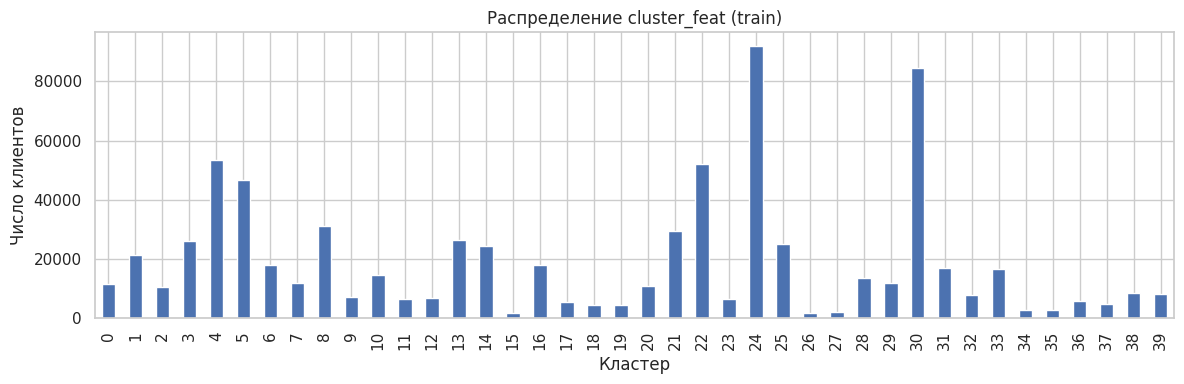

In [24]:
import matplotlib.pyplot as plt

cluster_counts = pd.Series(train_df['cluster_feat']).value_counts().sort_index()

plt.figure(figsize=(12, 4))
cluster_counts.plot(kind='bar')
plt.title('Распределение cluster_feat (train)')
plt.xlabel('Кластер')
plt.ylabel('Число клиентов')
plt.tight_layout()
plt.show()


## Приведение типов
Понижение `float64` до `float32` для экономии памяти.

In [25]:
for col in train_df.columns:
    if train_df[col].dtype == 'float64':
        train_df[col] = train_df[col].astype('float32')
        test_df[col] = test_df[col].astype('float32')


## Быстрый отбор признаков по важности
Обучается quick-модель CatBoost для получения `feat_imp`, после чего выбираются `selected_feats` и формируются `X_train_full`, `X_test_full`.

In [27]:

print("Быстрая предобучение для оценки важности (исправленный блок)...")

cat_features = [c for c in cat_features if not str(c).startswith('cluster_dist_')]
cat_features = [c for c in cat_features if c in train_df.columns]

import pandas as pd
import numpy as np

def sanitize_cat_columns_for_catboost(df, cats):
    prepared = []
    for c in cats:
        if c not in df.columns:
            continue
        col = df[c]
        if pd.api.types.is_object_dtype(col) or pd.api.types.is_string_dtype(col):
            df[c] = col.fillna('nan').astype(str)
            prepared.append(c)
            continue
        if pd.api.types.is_float_dtype(col):
            non_null = col.dropna()
            if non_null.size == 0:
                df[c] = col.fillna('nan').astype(str)
            else:
                arr = non_null.values
                if np.all(np.isclose(arr % 1, 0.0, atol=1e-8)):
                    df[c] = col.fillna(-999).astype(np.int32).astype(str)
                else:
                    df[c] = col.fillna('nan').astype(str)
            prepared.append(c)
            continue
        if pd.api.types.is_integer_dtype(col):
            df[c] = col.fillna(-999).astype(np.int32).astype(str)
            prepared.append(c)
            continue
        df[c] = col.fillna('nan').astype(str)
        prepared.append(c)
    return prepared

all_feats = sorted([c for c in train_df.columns if c != 'customer_id'])
X_quick = train_df[all_feats].copy()
y_quick = y_df.copy()

X_tr, X_val, y_tr, y_val = train_test_split(X_quick, y_quick, test_size=0.15, random_state=RANDOM_SEED)

cat_present = sanitize_cat_columns_for_catboost(X_tr, cat_features)
_ = sanitize_cat_columns_for_catboost(X_val, cat_present)

pool_tr = Pool(data=X_tr, label=y_tr, cat_features=cat_present)
pool_val = Pool(data=X_val, label=y_val, cat_features=cat_present)

catboost_params = {
    'loss_function': 'MultiLogloss', 'iterations': 1200,
    'learning_rate': 0.05, 'depth': 6, 'l2_leaf_reg': 6,
    'rsm': RSM, 'random_strength': 1.2, 'task_type': 'GPU',
    'devices': '0', 'verbose': 200, 'bootstrap_type': 'Bernoulli',
    'allow_writing_files': False
}

print("Training quick model for feature importance...")
quick_model = CatBoostClassifier(**catboost_params)
quick_model.fit(pool_tr, eval_set=pool_val, early_stopping_rounds=50, use_best_model=True)

fi = quick_model.get_feature_importance(type='FeatureImportance', data=pool_val)
feat_imp = pd.DataFrame({'feature': quick_model.feature_names_, 'importance': fi})
feat_imp = feat_imp.sort_values('importance', ascending=False)

if TOP_FEATS:
    selected_feats = feat_imp['feature'].values[:TOP_FEATS].tolist()
else:
    selected_feats = feat_imp['feature'].values.tolist()

print(f"Отобрано {len(selected_feats)} лучших признаков.")

X_train_full = train_df[selected_feats].copy()
y_train_full = y_df.copy()
X_test_full = test_df[selected_feats].copy()


Быстрая предобучение для оценки важности (исправленный блок)...
Training quick model for feature importance...
0:	learn: 0.5798100	test: 0.5798001	best: 0.5798001 (0)	total: 574ms	remaining: 11m 28s
200:	learn: 0.0855686	test: 0.0860809	best: 0.0860809 (200)	total: 1m 7s	remaining: 5m 37s
400:	learn: 0.0831694	test: 0.0843247	best: 0.0843247 (400)	total: 2m 14s	remaining: 4m 28s
600:	learn: 0.0816675	test: 0.0834773	best: 0.0834773 (600)	total: 3m 21s	remaining: 3m 21s
800:	learn: 0.0805161	test: 0.0829637	best: 0.0829637 (800)	total: 4m 28s	remaining: 2m 13s
1000:	learn: 0.0795426	test: 0.0826144	best: 0.0826144 (1000)	total: 5m 35s	remaining: 1m 6s
1199:	learn: 0.0787301	test: 0.0823787	best: 0.0823787 (1199)	total: 6m 40s	remaining: 0us
bestTest = 0.08237869792
bestIteration = 1199
Отобрано 1500 лучших признаков.


## Важности признаков
Ниже визуализация `feat_imp`, полученных из quick-модели.

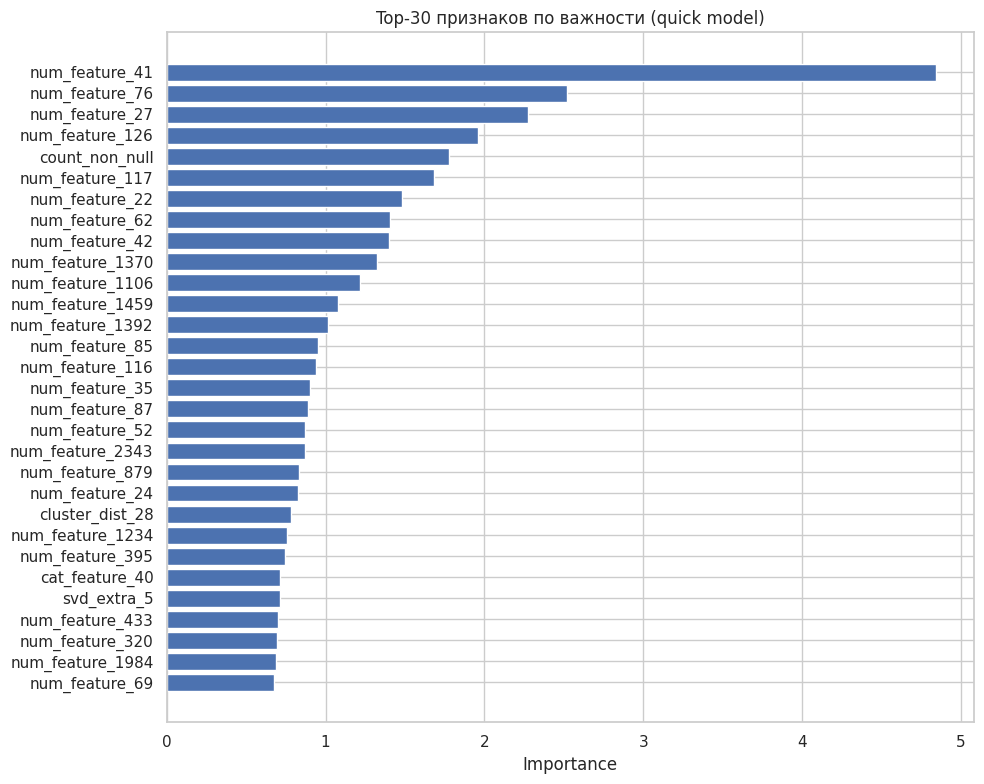

selected_feats: 1500


In [28]:
import matplotlib.pyplot as plt

top_k = 30
plot_df = feat_imp.head(top_k).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(plot_df['feature'], plot_df['importance'])
plt.title(f'Top-{top_k} признаков по важности (quick model)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('selected_feats:', len(selected_feats))


## Pseudo-labeling
Строится модель на всём train и генерируются hard-псевдометки для test (порог 0.5). Затем train и pseudo объединяются с весами `PSEUDO_WEIGHT`.

In [29]:
if USE_PSEUDO:
    print("Псевдомаркирование (HARD-label, совместимо с MultiLogloss)...")

    cat_present_final = [c for c in cat_features if c in X_train_full.columns]
    cat_present_final = sanitize_cat_columns_for_catboost(X_train_full, cat_present_final)
    _ = sanitize_cat_columns_for_catboost(X_test_full, cat_present_final)

    pool_full = Pool(
        data=X_train_full,
        label=y_train_full,
        cat_features=cat_present_final
    )

    pseudo_model = CatBoostClassifier(
        **catboost_params
    )
    pseudo_model.fit(pool_full, verbose=False)

    preds_test_proba = pseudo_model.predict_proba(
        Pool(X_test_full, cat_features=cat_present_final)
    )

    pseudo_labels = (preds_test_proba > 0.5).astype(np.int8)
    pseudo_labels = pd.DataFrame(pseudo_labels, columns=y_train_full.columns)

    X_pseudo = pd.concat(
        [X_train_full.reset_index(drop=True),
         X_test_full.reset_index(drop=True)],
        ignore_index=True
    )

    y_pseudo = pd.concat(
        [y_train_full.reset_index(drop=True),
         pseudo_labels.reset_index(drop=True)],
        ignore_index=True
    )

    w = np.concatenate([
        np.ones(len(X_train_full), dtype=np.float32),
        np.ones(len(X_test_full), dtype=np.float32) * PSEUDO_WEIGHT
    ])
else:
    print("Псевдомаркирование отключено.")
    X_pseudo = X_train_full.reset_index(drop=True)
    y_pseudo = y_train_full.reset_index(drop=True)
    w = None


Псевдомаркирование (HARD-label, совместимо с MultiLogloss)...


## Финальный train/val split
Случайное разделение объединённого датасета на train/val для финального обучения.

In [30]:
print("Финальный train/val split...")

idx = np.arange(len(X_pseudo))
tr_idx, val_idx = train_test_split(
    idx, test_size=0.1, random_state=RANDOM_SEED, shuffle=True
)

X_tr = X_pseudo.iloc[tr_idx].reset_index(drop=True)
X_val = X_pseudo.iloc[val_idx].reset_index(drop=True)
y_tr = y_pseudo.iloc[tr_idx].reset_index(drop=True)
y_val = y_pseudo.iloc[val_idx].reset_index(drop=True)

w_tr = w[tr_idx] if w is not None else None
w_val = w[val_idx] if w is not None else None

cat_present_final = [c for c in cat_present_final if c in X_tr.columns]
cat_present_final = sanitize_cat_columns_for_catboost(X_tr, cat_present_final)
_ = sanitize_cat_columns_for_catboost(X_val, cat_present_final)
_ = sanitize_cat_columns_for_catboost(X_test_full, cat_present_final)

train_pool = Pool(
    X_tr, y_tr,
    cat_features=cat_present_final,
    weight=w_tr
)

val_pool = Pool(
    X_val, y_val,
    cat_features=cat_present_final,
    weight=w_val
)


Финальный train/val split...


## Финальная модель CatBoost (GPU) 
Обучение CatBoost с `MultiLogloss`, ранней остановкой и использованием GPU.

In [33]:
print("Финальное обучение CatBoost (GPU, MultiLogloss)...")

final_params = {
    'loss_function': 'MultiLogloss',
    'iterations': ITER_FINAL,
    'learning_rate': 0.02,
    'depth': 8,
    'l2_leaf_reg': 8,
    'rsm': RSM,
    'random_strength': 1.5,
    'task_type': 'GPU',
    'devices': '0',
    'verbose': 200,
    'bootstrap_type': 'Bernoulli',
    'allow_writing_files': False
}

final_model = CatBoostClassifier(**final_params)
final_model.fit(
    train_pool,
    eval_set=val_pool,
    early_stopping_rounds=EARLY_STOP,
    use_best_model=True
)


Финальное обучение CatBoost (GPU, MultiLogloss)...
0:	learn: 0.6448149	test: 0.6448262	best: 0.6448262 (0)	total: 663ms	remaining: 22m 5s
200:	learn: 0.0839980	test: 0.0843814	best: 0.0843814 (200)	total: 2m 15s	remaining: 20m 12s
400:	learn: 0.0812621	test: 0.0822679	best: 0.0822679 (400)	total: 4m 31s	remaining: 18m 1s
600:	learn: 0.0795709	test: 0.0812084	best: 0.0812084 (600)	total: 6m 47s	remaining: 15m 47s
800:	learn: 0.0783751	test: 0.0805707	best: 0.0805707 (800)	total: 9m	remaining: 13m 29s
1000:	learn: 0.0773476	test: 0.0801121	best: 0.0801121 (1000)	total: 11m 14s	remaining: 11m 13s
1200:	learn: 0.0764742	test: 0.0797854	best: 0.0797854 (1200)	total: 13m 27s	remaining: 8m 57s
1400:	learn: 0.0756728	test: 0.0795312	best: 0.0795312 (1400)	total: 15m 41s	remaining: 6m 42s
1600:	learn: 0.0749194	test: 0.0793241	best: 0.0793241 (1600)	total: 17m 54s	remaining: 4m 27s
1800:	learn: 0.0742002	test: 0.0791461	best: 0.0791461 (1800)	total: 20m 8s	remaining: 2m 13s
1999:	learn: 0.07354

## Разбор ROC-AUC по таргетам
Дополнительно считаем ROC-AUC по каждому таргету и смотрим распределение значений.

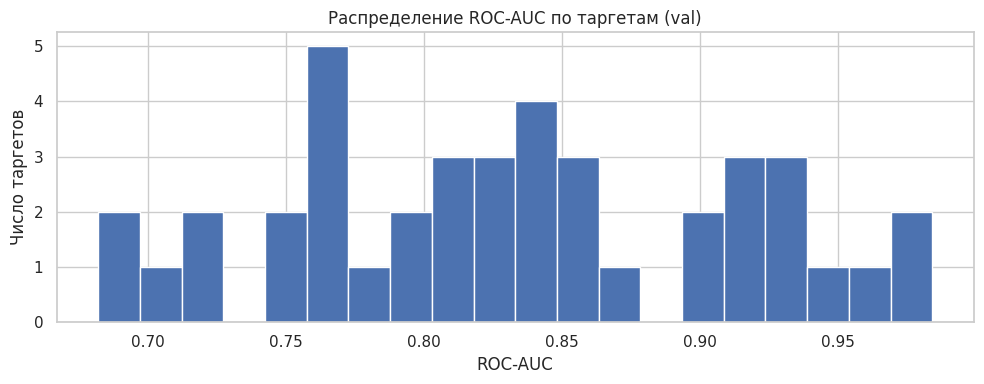

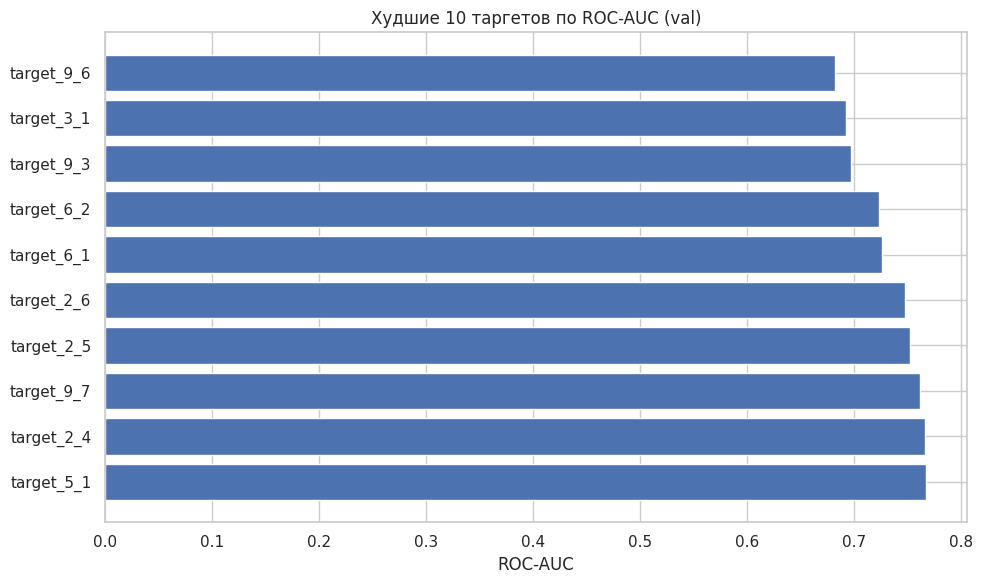

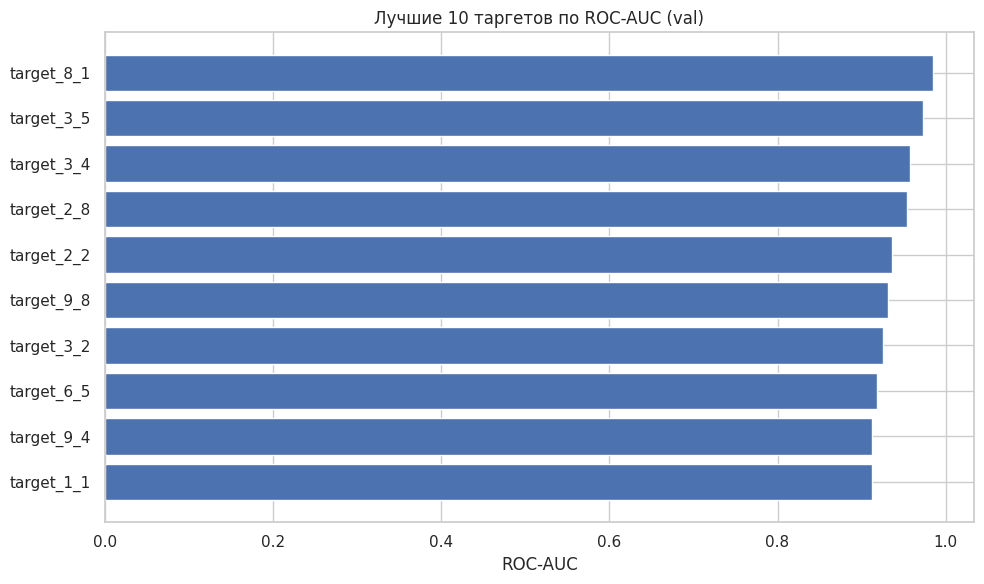

In [35]:
import matplotlib.pyplot as plt

auc_by_target = []
for i, col in enumerate(y_val.columns):
    try:
        auc = roc_auc_score(y_val.iloc[:, i], val_pred[:, i])
        auc_by_target.append((col, float(auc)))
    except Exception:
        continue

auc_df = pd.DataFrame(auc_by_target, columns=['target', 'roc_auc']).sort_values('roc_auc')

plt.figure(figsize=(10, 4))
plt.hist(auc_df['roc_auc'], bins=20)
plt.title('Распределение ROC-AUC по таргетам (val)')
plt.xlabel('ROC-AUC')
plt.ylabel('Число таргетов')
plt.tight_layout()
plt.show()

worst = auc_df.head(10).iloc[::-1]
best = auc_df.tail(10)

plt.figure(figsize=(10, 6))
plt.barh(worst['target'], worst['roc_auc'])
plt.title('Худшие 10 таргетов по ROC-AUC (val)')
plt.xlabel('ROC-AUC')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.barh(best['target'], best['roc_auc'])
plt.title('Лучшие 10 таргетов по ROC-AUC (val)')
plt.xlabel('ROC-AUC')
plt.tight_layout()
plt.show()


## Submission
Предсказания на тесте сохраняются в parquet в формате, совместимом с `sample_submit.parquet`.

In [38]:
print("Финальное предсказание и сохранение submission...")

preds_test = final_model.predict_proba(
    Pool(X_test_full, cat_features=cat_present_final)
)

sample_sub = pl.read_parquet(SAMPLE_SUB_PATH)
pred_cols = [c for c in sample_sub.columns if c != 'customer_id']

arrays = [customer_ids.astype(np.int32)] + [
    preds_test[:, i].astype(np.float64) for i in range(len(pred_cols))
]

schema = pa.schema(
    [('customer_id', pa.int32())] +
    [(c, pa.float64()) for c in pred_cols]
)

pq.write_table(
    pa.Table.from_arrays(arrays, schema=schema),
    FINAL_SUBMIT,
    compression='snappy'
)

print("Сохранено:", FINAL_SUBMIT)
print("PIPELINE FINISHED SUCCESSFULLY")


Финальное предсказание и сохранение submission...
Сохранено: submission_0_836.parquet
PIPELINE FINISHED SUCCESSFULLY


Вообщем данный код выдает на public: 0,83639

Спасибо за внимание :P

Контакт для связи (Telegram): @Roman_Tamrazov